In [32]:
!pip install numpy scipy scikit-learn matplotlib tensorflow pandas

  Using cached pandas-3.0.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
Using cached pandas-3.0.2-cp313-cp313-macosx_11_0_arm64.whl (9.9 MB)

[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


# A.

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [10]:
data_dir = os.getcwd()
print("Using data folder:", data_dir)

Using data folder: /Users/talenttools/Documents/Deep-learning-INFOMDLR-Group-9/LSTM


In [11]:
file_path = os.path.join(data_dir, "../Xtrain.mat")

print("File exists:", os.path.exists(file_path))

File exists: True


In [12]:
mat_data = scipy.io.loadmat(file_path)

print("Variables inside the .mat file:")
print(mat_data.keys())

Variables inside the .mat file:
dict_keys(['__header__', '__version__', '__globals__', 'Xtrain'])


In [13]:
Xtrain = mat_data["Xtrain"]

print("Type:", type(Xtrain))
print("Original shape:", Xtrain.shape)

Type: <class 'numpy.ndarray'>
Original shape: (1000, 1)


In [14]:
#flatten the data since LSTM expects 2D input (samples, features)

series = Xtrain.flatten()

print("Flattened shape:", series.shape)
print("First 10 values:")
print(series[:10])

Flattened shape: (1000,)
First 10 values:
[ 86 141  95  41  22  21  32  72 138 111]


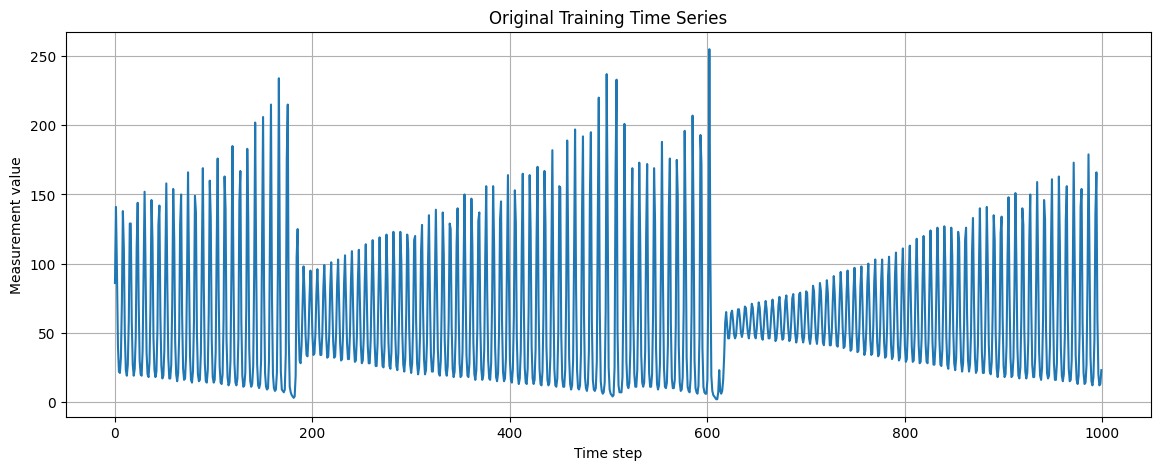

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(series)
plt.title("Original Training Time Series")
plt.xlabel("Time step")
plt.ylabel("Measurement value")
plt.grid(True)
plt.show()

In [16]:
scaler = MinMaxScaler(feature_range=(0, 1))

series_scaled = scaler.fit_transform(series.reshape(-1, 1))

print("Scaled shape:", series_scaled.shape)
print("First 10 scaled values:")
print(series_scaled[:10])

Scaled shape: (1000, 1)
First 10 scaled values:
[[0.33201581]
 [0.54940711]
 [0.36758893]
 [0.1541502 ]
 [0.07905138]
 [0.07509881]
 [0.11857708]
 [0.27667984]
 [0.53754941]
 [0.43083004]]


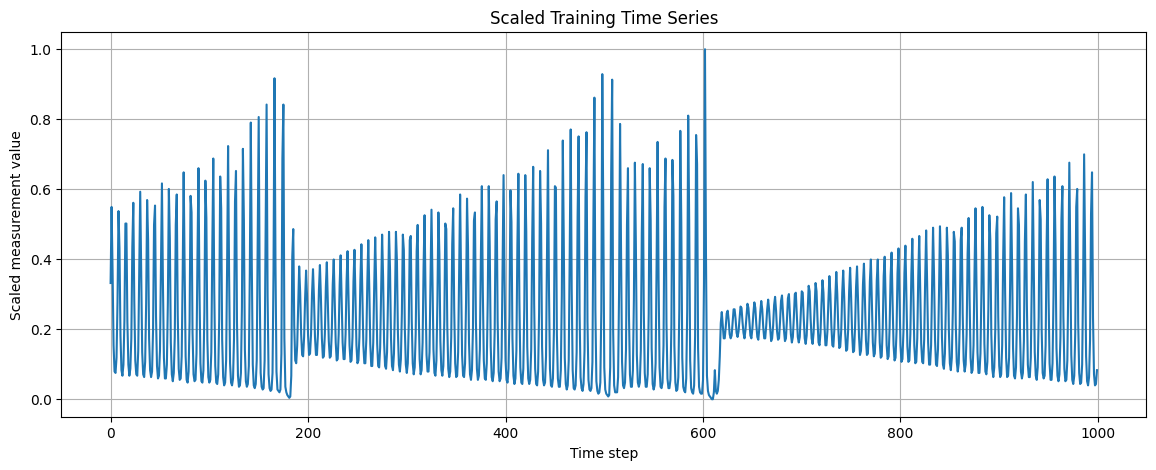

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(series_scaled)
plt.title("Scaled Training Time Series")
plt.xlabel("Time step")
plt.ylabel("Scaled measurement value")
plt.grid(True)
plt.show()

In [18]:
def create_sequences(data, time_steps):
    X = []
    y = []

    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])

    return np.array(X), np.array(y)

In [19]:
time_steps = 50

X, y = create_sequences(series_scaled, time_steps)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (950, 50, 1)
y shape: (950, 1)


In [20]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:]
y_val = y[train_size:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (760, 50, 1)
y_train: (760, 1)
X_val: (190, 50, 1)
y_val: (190, 1)


In [21]:
model = Sequential()

model.add(LSTM(
    units=64,
    input_shape=(time_steps, 1)
))

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/Users/talenttools/Documents/Deep-learning-INFOMDLR-Group-9/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0480 - val_loss: 0.0356
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0373 - val_loss: 0.0325
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0356 - val_loss: 0.0307
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0333 - val_loss: 0.0281
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0305 - val_loss: 0.0246
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0263 - val_loss: 0.0185
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0199 - val_loss: 0.0080
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0144 - val_loss: 0.0074
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0132 - val_loss: 0.0074
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0120 - val_loss: 0.0064
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0116 - val_loss: 0.0060
Epoch 12/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0

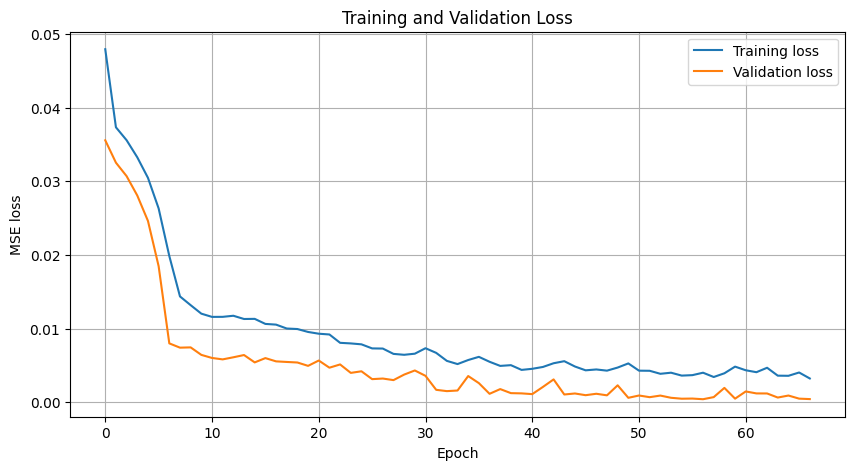

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
y_val_pred_scaled = model.predict(X_val)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [25]:
y_val_pred = scaler.inverse_transform(y_val_pred_scaled)
y_val_real = scaler.inverse_transform(y_val)

In [26]:
val_mae = mean_absolute_error(y_val_real, y_val_pred)
val_mse = mean_squared_error(y_val_real, y_val_pred)

print("Validation MAE:", val_mae)
print("Validation MSE:", val_mse)

Validation MAE: 3.867928951664975
Validation MSE: 25.95664088989242


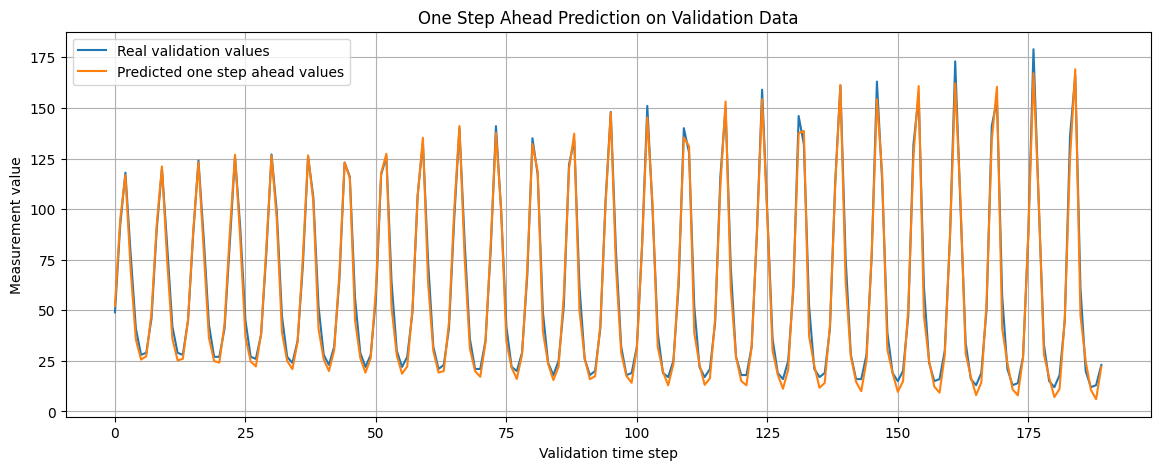

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(y_val_real, label="Real validation values")
plt.plot(y_val_pred, label="Predicted one step ahead values")
plt.title("One Step Ahead Prediction on Validation Data")
plt.xlabel("Validation time step")
plt.ylabel("Measurement value")
plt.legend()
plt.grid(True)
plt.show()

# B.

In [28]:
def build_lstm_model(time_steps):
    model = Sequential()

    model.add(LSTM(
        units=64,
        input_shape=(time_steps, 1)
    ))

    model.add(Dropout(0.2))

    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

In [29]:
# Choosing different time steps to evaluate the model's performance
time_steps_list = [10, 20, 50, 100, 150, 200]

In [30]:
results = []

for ts in time_steps_list:
    print("=" * 50)
    print("Training model with time_steps =", ts)

    # Create sequences for this time step value
    X, y = create_sequences(series_scaled, ts)

    # Time series split, no random shuffle
    train_size = int(len(X) * 0.8)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:]
    y_val = y[train_size:]

    # Build fresh model
    model_temp = build_lstm_model(ts)

    # Early stopping
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    # Train model
    history_temp = model_temp.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        shuffle=False,
        verbose=0
    )

    # Predict validation data
    y_val_pred_scaled = model_temp.predict(X_val, verbose=0)

    # Scale back to original values
    y_val_pred = scaler.inverse_transform(y_val_pred_scaled)
    y_val_real = scaler.inverse_transform(y_val)

    # Calculate metrics
    val_mae = mean_absolute_error(y_val_real, y_val_pred)
    val_mse = mean_squared_error(y_val_real, y_val_pred)

    print("Validation MAE:", val_mae)
    print("Validation MSE:", val_mse)

    # Store results
    results.append({
        "time_steps": ts,
        "val_mae": val_mae,
        "val_mse": val_mse,
        "model": model_temp,
        "history": history_temp
    })

Training model with time_steps = 10


/Users/talenttools/Documents/Deep-learning-INFOMDLR-Group-9/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Validation MAE: 3.224131372239855
Validation MSE: 18.69651830489597
Training model with time_steps = 20


/Users/talenttools/Documents/Deep-learning-INFOMDLR-Group-9/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Validation MAE: 5.139840627203182
Validation MSE: 42.55998024932154
Training model with time_steps = 50


...

Validation MAE: 4.0863823334376015
Validation MSE: 29.900270066480225
Training model with time_steps = 150


/Users/talenttools/Documents/Deep-learning-INFOMDLR-Group-9/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Validation MAE: 15.091530258515302
Validation MSE: 389.4651036396564
Training model with time_steps = 200


/Users/talenttools/Documents/Deep-learning-INFOMDLR-Group-9/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Validation MAE: 4.80044871866703
Validation MSE: 37.43096030076497


In [33]:
import pandas as pd

results_df = pd.DataFrame([
    {
        "time_steps": r["time_steps"],
        "val_mae": r["val_mae"],
        "val_mse": r["val_mse"]
    }
    for r in results
])

results_df = results_df.sort_values(by="val_mse")

print(results_df)

   time_steps    val_mae     val_mse
0          10   3.224131   18.696518
3         100   4.086382   29.900270
2          50   4.217208   31.352492
5         200   4.800449   37.430960
1          20   5.139841   42.559980
4         150  15.091530  389.465104


In [34]:
best_result = results_df.iloc[0]

best_time_steps = int(best_result["time_steps"])
best_val_mae = best_result["val_mae"]
best_val_mse = best_result["val_mse"]

print("Best time_steps:", best_time_steps)
print("Best validation MAE:", best_val_mae)
print("Best validation MSE:", best_val_mse)

Best time_steps: 10
Best validation MAE: 3.224131372239855
Best validation MSE: 18.69651830489597


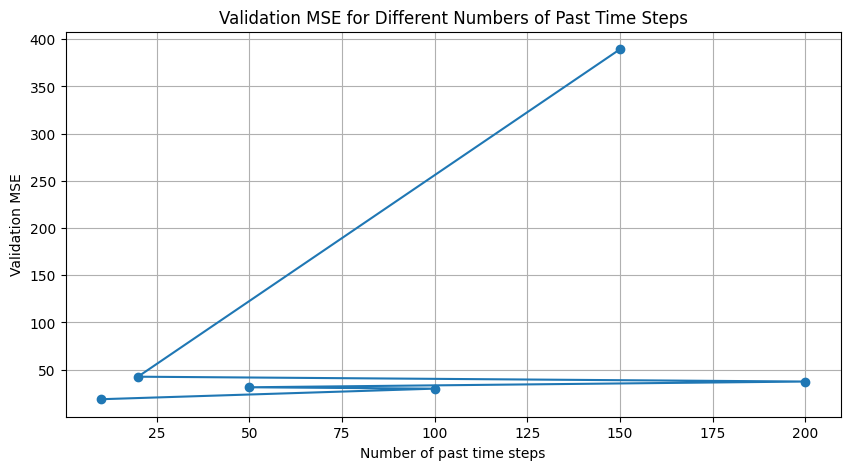

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(results_df["time_steps"], results_df["val_mse"], marker="o")
plt.title("Validation MSE for Different Numbers of Past Time Steps")
plt.xlabel("Number of past time steps")
plt.ylabel("Validation MSE")
plt.grid(True)
plt.show()

In [36]:
best_model = None
best_history = None

for r in results:
    if r["time_steps"] == best_time_steps:
        best_model = r["model"]
        best_history = r["history"]
        break

print("Best model selected with time_steps =", best_time_steps)

Best model selected with time_steps = 10
